In [1]:
import matplotlib as mpl
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import glob

In [2]:
1/0.33407

2.993384619989823

In [3]:
# known_tois = pd.read_csv('../data/toi-catalog.csv', skiprows =2)
known_tois = pd.read_csv('../data/PS_2026.02.17_18.13.58.csv', skiprows =110)

known_tois


,pl_name,hostname,tic_id,gaia_dr3_id,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,...,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_tmag,sy_tmagerr1,sy_tmagerr2,rowupdate,pl_pubdate,releasedate
0,LP 890-9 b,LP 890-9,TIC 44898913,Gaia DR3 4886243456388510720,1,1,2,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.82130,0.000763,-0.000763,14.2683,0.007557,-0.007557,2022-09-14,2022-09,2022-09-14
1,LP 791-18 b,LP 791-18,TIC 181804752,Gaia DR3 3562427951852172288,1,1,3,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.07150,0.001324,-0.001324,13.5571,0.007732,-0.007732,2023-05-14,2023-05,2023-05-14
2,LP 791-18 c,LP 791-18,TIC 181804752,Gaia DR3 3562427951852172288,1,1,3,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.07150,0.001324,-0.001324,13.5571,0.007732,-0.007732,2023-05-14,2023-05,2023-05-14
3,LHS 3844 b,LHS 3844,TIC 410153553,Gaia DR3 6385548541499112448,1,1,1,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,13.39250,0.000738,-0.000738,11.9238,0.007698,-0.007698,2019-01-22,2019-02,2019-01-24
4,TOI-540 b,TOI-540,TIC 200322593,Gaia DR3 4785886941312921344,1,1,1,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),...,-0.021,12.89380,0.000481,-0.000481,11.5045,0.007318,-0.007318,2020-10-01,2021-01,2020-10-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,TOI-2427 b,TOI-2427,TIC 142937186,Gaia DR3 5055663973297050624,1,1,1,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.024,9.81845,0.000540,-0.000540,9.0138,0.006000,-0.006000,2022-02-15,2022-02,2022-02-15
187,TOI-3757 b,TOI-3757,TIC 445751830,Gaia DR3 996878131494639488,1,1,1,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.020,14.13210,0.000442,-0.000442,13.1858,0.007332,-0.007332,2022-08-22,2022-09,2022-08-22
188,TOI-6303 b,TOI-6303,TIC 186810676,Gaia DR3 239050153051494272,1,1,1,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),...,-0.016,13.91140,0.000482,-0.000482,12.9386,0.007343,-0.007343,2025-09-17,2025-07,2025-09-17
189,TOI-2379 b,TOI-2379,TIC 201177276,Gaia DR3 6521531466699512064,1,1,1,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,14.66010,0.000323,-0.000323,13.6521,0.007308,-0.007308,2024-09-17,2024-10,2024-09-17


In [4]:
tic_ids = ['TIC '+(file.split('/')[2].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/*check')]

In [5]:
tic_ids

['TIC 243185500',
 'TIC 163539739',
 'TIC 36724087',
 'TIC 299798795',
 'TIC 348755728',
 'TIC 285048486',
 'TIC 308120029',
 'TIC 103633434',
 'TIC 201177276',
 'TIC 384888319',
 'TIC 328081248',
 'TIC 220479565',
 'TIC 150428135',
 'TIC 260708537',
 'TIC 178709444',
 'TIC 181804752',
 'TIC 18318288',
 'TIC 26054627',
 'TIC 186810676',
 'TIC 201186294',
 'TIC 27649847',
 'TIC 28900646',
 'TIC 4070275',
 'TIC 4918918',
 'TIC 186810676',
 'TIC 188589164',
 'TIC 192833836',
 'TIC 193336820',
 'TIC 193634953',
 'TIC 155867025',
 'TIC 144700903',
 'TIC 119584412',
 'TIC 12421862',
 'TIC 118327550',
 'TIC 102734241',
 'TIC 112115898',
 'TIC 126606859',
 'TIC 151825527',
 'TIC 158588995',
 'TIC 389900760',
 'TIC 28900646',
 'TIC 8348911',
 'TIC 198385543',
 'TIC 198485881',
 'TIC 200322593',
 'TIC 201177276',
 'TIC 201186294',
 'TIC 20182780',
 'TIC 212957629',
 'TIC 218795833',
 'TIC 219041246',
 'TIC 219698776',
 'TIC 219860288',
 'TIC 219875976',
 'TIC 220479565',
 'TIC 165202476',
 'TIC 

In [6]:
failed_2 = ['TIC '+(file.split('/')[-1].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/*data')]




failed_1 = ['TIC '+(file.split('/')[-1].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/t*') if 'data' not in file.split('/')[-1]]



In [7]:
failed_2

['TIC 116483514',
 'TIC 119585136',
 'TIC 142937186',
 'TIC 230055368',
 'TIC 357501308',
 'TIC 382602147',
 'TIC 417931300',
 'TIC 439867639',
 'TIC 470381900',
 'TIC 50618703']

In [8]:
known_tois.columns

Index(['pl_name', 'hostname', 'tic_id', 'gaia_dr3_id', 'default_flag',
       'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility',
       'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper',
       'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax',
       'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade',
       'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1',
       'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1',
       'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1',
       'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype',
       'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad',
       'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 's

In [9]:
known_tois['transit_depth'] = (known_tois.pl_rade/known_tois.st_rad/109.076)**2

In [ ]:
known_tois

In [10]:
searched_tois = known_tois[known_tois['default_flag']==1].reset_index(drop=True)[['tic_id', 'pl_orbper', 'transit_depth', 'sy_pnum', 'pl_rade']]

# searched_tois.TIC = 'TIC '+str(searched_tois.TIC)


In [11]:
# known_tois.pl_rade/known_tois.st_rad/109.076

In [12]:
# searched_tois = searched_tois[searched_tois['Orbital Period (days) Value']<1E3]

In [13]:
# set(searched_tois['TOI Disposition'])

In [14]:
# searched_tois['Transit Depth Value'] = searched_tois['Transit Depth Value']/1E6
searched_tois

,tic_id,pl_orbper,transit_depth,sy_pnum,pl_rade
0,TIC 44898913,2.729903,0.006049,2,1.320000
1,TIC 181804752,0.947998,0.003727,3,1.212000
2,TIC 181804752,4.989909,0.015082,3,2.438000
3,TIC 410153553,0.462929,0.003995,1,1.303000
4,TIC 200322593,1.239149,0.001909,1,0.903000
...,...,...,...,...,...
186,TIC 142937186,1.306001,0.000645,1,1.800000
187,TIC 445751830,3.438753,0.031486,1,12.000000
188,TIC 186810676,9.485236,0.030442,1,11.590000
189,TIC 201177276,5.469383,0.029865,1,11.724594


In [15]:
len(set(searched_tois.tic_id))

161

In [35]:
convergence_test_files_singles = glob.glob('../fit_stats/S*')



convergence_test_files_periodic = glob.glob('../fit_stats/P*')


len(convergence_test_files_singles), len(convergence_test_files_periodic)

(284, 118)

In [ ]:
# convergence_test_files_singles = glob.glob('../checking_convergence_output/confidence_0.55/*single*.csv')



# convergence_test_files_periodic = glob.glob('../checking_convergence_output/confidence_0.55/*per*.csv')


# len(convergence_test_files_singles), len(convergence_test_files_periodic)

(0, 0)

In [57]:
convergence_test_files_singles = glob.glob('../checking_convergence_output/*single*final.csv')



convergence_test_files_periodic = glob.glob('../checking_convergence_output/*per*final.csv')


len(convergence_test_files_singles), len(convergence_test_files_periodic)

(113, 292)

In [58]:
# convergence_test_files_singles = glob.glob('../checking_convergence_output/*single*.csv')



# convergence_test_files_periodic = glob.glob('../checking_convergence_output/*per*.csv')


# len(convergence_test_files_singles), len(convergence_test_files_periodic)

In [ ]:
converg_tests_singles= pd.concat((pd.read_csv(f) for f in convergence_test_files_singles), ignore_index=True)
converg_tests_singles['TICID'] = ['TIC '+str(converg_tests_singles['ticid'][x] ) for x in range(len(converg_tests_singles))]

converg_tests_singles

,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID
0,98796344,5153091836072107136,Single|t0=1433.49322,Single,1,2000,5000,4,1,1.03,TIC 98796344
1,343628284,2189711770761074816,Single|t0=1772.54411,Single,1,2000,5000,4,1,1.01,TIC 343628284
2,163539739,1867491607542113536,Single|t0=1711.97055,Single,1,2000,5000,4,1,1.03,TIC 163539739
3,155867025,178924390478792320,Single|t0=1818.96228,Single,1,2000,5000,4,1,1.03,TIC 155867025
4,144700903,3340265717587057536,Single|t0=1472.90955,Single,1,2000,5000,4,1,1.02,TIC 144700903
...,...,...,...,...,...,...,...,...,...,...,...
279,259377017,4781196115469953024,Single|t0=1457.41088,Single,2,4000,10000,4,1,1.01,TIC 259377017
280,259377017,4781196115469953024,Single|t0=1451.85274,Single,2,4000,10000,4,1,1.00,TIC 259377017
281,259377017,4781196115469953024,Single|t0=1412.14256,Single,1,2000,5000,4,1,1.02,TIC 259377017
282,259377017,4781196115469953024,Single|t0=1400.86872,Single,2,4000,10000,4,1,1.02,TIC 259377017


In [33]:
convergence_test_files_periodic

[]

In [39]:
converg_tests_periodic = pd.concat((pd.read_csv(f) for f in convergence_test_files_periodic), ignore_index=True)
converg_tests_periodic['TICID'] = ['TIC '+str(converg_tests_periodic.ticid[x] ) for x in range(len(converg_tests_periodic))]

converg_tests_periodic

,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID
0,153078576,48470013022774,Periodic|P=47.572409|t0=1387.89833,Periodic,1,2000,5000,4,1,1.07,TIC 153078576
1,95057860,2997312063605005056,Periodic|P=6.498232|t0=1474.54246,Periodic,1,2000,5000,4,1,1.04,TIC 95057860
2,285048486,1094545653447816064,Periodic|P=1.67713|t0=1842.54105,Periodic,1,2000,5000,4,1,1.09,TIC 285048486
3,458419328,1044013542142711296,Periodic|P=9.355564|t0=1842.78118,Periodic,2,4000,10000,4,1,1.02,TIC 458419328
4,306996324,3460438662009633408,Periodic|P=10.734272|t0=1578.71211,Periodic,2,4000,10000,4,1,1.02,TIC 306996324
...,...,...,...,...,...,...,...,...,...,...,...
113,259377017,4781196115469953024,Periodic|P=8.491725|t0=2119.71216,Periodic,3,6000,15000,4,1,1.01,TIC 259377017
114,259377017,4781196115469953024,Periodic|P=0.808312|t0=1385.5108,Periodic,2,4000,10000,4,1,1.02,TIC 259377017
115,271971130,5262666416118954368,Periodic|P=9.271048|t0=1329.76526,Periodic,3,6000,15000,4,1,1.01,TIC 271971130
116,260708537,5482827676662168832,Periodic|P=0.284571|t0=1330.04431,Periodic,4,8000,20000,4,1,1.06,TIC 260708537


In [ ]:
converg_tests_periodic

,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID,period
0,153078576,48470013022774,Periodic|P=47.572409|t0=1387.89833,Periodic,1,2000,5000,4,1,1.07,TIC 153078576,47.572409
1,95057860,2997312063605005056,Periodic|P=6.498232|t0=1474.54246,Periodic,1,2000,5000,4,1,1.04,TIC 95057860,6.498232
2,285048486,1094545653447816064,Periodic|P=1.67713|t0=1842.54105,Periodic,1,2000,5000,4,1,1.09,TIC 285048486,1.677130
3,458419328,1044013542142711296,Periodic|P=9.355564|t0=1842.78118,Periodic,2,4000,10000,4,1,1.02,TIC 458419328,9.355564
4,306996324,3460438662009633408,Periodic|P=10.734272|t0=1578.71211,Periodic,2,4000,10000,4,1,1.02,TIC 306996324,10.734272
...,...,...,...,...,...,...,...,...,...,...,...,...
113,259377017,4781196115469953024,Periodic|P=8.491725|t0=2119.71216,Periodic,3,6000,15000,4,1,1.01,TIC 259377017,8.491725
114,259377017,4781196115469953024,Periodic|P=0.808312|t0=1385.5108,Periodic,2,4000,10000,4,1,1.02,TIC 259377017,0.808312
115,271971130,5262666416118954368,Periodic|P=9.271048|t0=1329.76526,Periodic,3,6000,15000,4,1,1.01,TIC 271971130,9.271048
116,260708537,5482827676662168832,Periodic|P=0.284571|t0=1330.04431,Periodic,4,8000,20000,4,1,1.06,TIC 260708537,0.284571


In [71]:
converg_tests_singles['t0'] = [float(x[3:]) for x in np.array(list(converg_tests_singles.candidate_id.str.split('|')))[:,1]]    

converg_tests_singles


,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID,t0
0,98796344,5153091836072107136,Single|t0=1433.49322,Single,1,2000,5000,4,1,1.03,TIC 98796344,1433.49322
1,343628284,2189711770761074816,Single|t0=1772.54411,Single,1,2000,5000,4,1,1.01,TIC 343628284,1772.54411
2,163539739,1867491607542113536,Single|t0=1711.97055,Single,1,2000,5000,4,1,1.03,TIC 163539739,1711.97055
3,155867025,178924390478792320,Single|t0=1818.96228,Single,1,2000,5000,4,1,1.03,TIC 155867025,1818.96228
4,144700903,3340265717587057536,Single|t0=1472.90955,Single,1,2000,5000,4,1,1.02,TIC 144700903,1472.90955
...,...,...,...,...,...,...,...,...,...,...,...,...
279,259377017,4781196115469953024,Single|t0=1457.41088,Single,2,4000,10000,4,1,1.01,TIC 259377017,1457.41088
280,259377017,4781196115469953024,Single|t0=1451.85274,Single,2,4000,10000,4,1,1.00,TIC 259377017,1451.85274
281,259377017,4781196115469953024,Single|t0=1412.14256,Single,1,2000,5000,4,1,1.02,TIC 259377017,1412.14256
282,259377017,4781196115469953024,Single|t0=1400.86872,Single,2,4000,10000,4,1,1.02,TIC 259377017,1400.86872


In [ ]:
converg_tests_periodic['period'] = [float(x[2:]) for x in np.array(list(converg_tests_periodic.candidate_id.str.split('|')))[:,1]]    
converg_tests_periodic['t0'] = [float(x[3:]) for x in np.array(list(converg_tests_periodic.candidate_id.str.split('|')))[:,2]]    

converg_tests_periodic

,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID,period,t0
0,153078576,48470013022774,Periodic|P=47.572409|t0=1387.89833,Periodic,1,2000,5000,4,1,1.07,TIC 153078576,47.572409,1387.89833
1,95057860,2997312063605005056,Periodic|P=6.498232|t0=1474.54246,Periodic,1,2000,5000,4,1,1.04,TIC 95057860,6.498232,1474.54246
2,285048486,1094545653447816064,Periodic|P=1.67713|t0=1842.54105,Periodic,1,2000,5000,4,1,1.09,TIC 285048486,1.677130,1842.54105
3,458419328,1044013542142711296,Periodic|P=9.355564|t0=1842.78118,Periodic,2,4000,10000,4,1,1.02,TIC 458419328,9.355564,1842.78118
4,306996324,3460438662009633408,Periodic|P=10.734272|t0=1578.71211,Periodic,2,4000,10000,4,1,1.02,TIC 306996324,10.734272,1578.71211
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,259377017,4781196115469953024,Periodic|P=8.491725|t0=2119.71216,Periodic,3,6000,15000,4,1,1.01,TIC 259377017,8.491725,2119.71216
114,259377017,4781196115469953024,Periodic|P=0.808312|t0=1385.5108,Periodic,2,4000,10000,4,1,1.02,TIC 259377017,0.808312,1385.51080
115,271971130,5262666416118954368,Periodic|P=9.271048|t0=1329.76526,Periodic,3,6000,15000,4,1,1.01,TIC 271971130,9.271048,1329.76526
116,260708537,5482827676662168832,Periodic|P=0.284571|t0=1330.04431,Periodic,4,8000,20000,4,1,1.06,TIC 260708537,0.284571,1330.04431


In [81]:
real_val_conv_test_singles = converg_tests_singles.copy()

In [ ]:
# real_val_conv_test_singles = converg_tests_singles.copy()
# real_val_conv_test_singles['int_multi'] = np.nan
# real_val_conv_test_singles['correct'] = False
# real_val_conv_test_singles['alias'] = False
# real_val_conv_test_singles['true_per'] = np.nan

# for indx, row in real_val_conv_test_singles.iterrows():
#     ticid = row.TICID
#     toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
#     t0_found  = row.t0
#     per_found = row.period
    
#     for toi_indx, toi_row in toi.iterrows():
# #         t0_known = toi_row['Orbital Epoch Value']
#         per_known = toi_row['pl_orbper']

# #         num_epochs = abs(t0_found-t0_known)/per_known

# #         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# # #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# # #         print(check_int)
# #         if check_int:
# #             real_val_conv_test_singles.loc[indx,'t0'] = t0_known
        
        
#         per_int = per_known/per_found
        
#         per_int_big = max([per_int, 1/per_int])
        
#         check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)

#         if check_per and (np.round(per_int_big)== 1):
#             real_val_conv_test_singles.loc[indx,'correct'] = True
#             real_val_conv_test_singles.loc[indx,'alias'] = True
#             real_val_conv_test_singles.loc[indx,'int_multi'] = 1
#             real_val_conv_test_singles.loc[indx,'true_per'] = per_known
#         elif check_per and (np.round(per_int_big)!= 1):
#             real_val_conv_test_singles.loc[indx,'correct'] = False
#             real_val_conv_test_singles.loc[indx,'alias'] = True
#             real_val_conv_test_singles.loc[indx,'int_multi'] = round(per_int)
#             real_val_conv_test_singles.loc[indx,'true_per'] = per_known
        

In [82]:
searched_tois

,tic_id,pl_orbper,transit_depth,sy_pnum,pl_rade
0,TIC 44898913,2.729903,0.006049,2,1.320000
1,TIC 181804752,0.947998,0.003727,3,1.212000
2,TIC 181804752,4.989909,0.015082,3,2.438000
3,TIC 410153553,0.462929,0.003995,1,1.303000
4,TIC 200322593,1.239149,0.001909,1,0.903000
...,...,...,...,...,...
186,TIC 142937186,1.306001,0.000645,1,1.800000
187,TIC 445751830,3.438753,0.031486,1,12.000000
188,TIC 186810676,9.485236,0.030442,1,11.590000
189,TIC 201177276,5.469383,0.029865,1,11.724594


In [ ]:
real_val_conv_test_periodic = converg_tests_periodic.copy()

real_val_conv_test_periodic['int_multi'] = np.nan
real_val_conv_test_periodic['correct'] = False
real_val_conv_test_periodic['alias'] = False
real_val_conv_test_periodic['true_per'] = np.nan

for indx, row in real_val_conv_test_periodic.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.period
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_periodic.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = True
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = 1
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = False
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = round(per_int)
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        

In [75]:
real_val_conv_test_singles[real_val_conv_test_singles['TICID'] == 'TIC 445751830']

,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID,t0,int_multi,correct,alias,true_per
9,445751830,996878131494639488,Single|t0=1831.91413,Single,1,2000,5000,4,1,1.02,TIC 445751830,1831.91413,NaN,False,False,NaN
16,445751830,996878131494639488,Single|t0=1818.1326,Single,1,2000,5000,4,1,1.03,TIC 445751830,1818.13260,NaN,False,False,NaN
37,445751830,996878131494639488,Single|t0=1821.57805,Single,1,2000,5000,4,1,1.02,TIC 445751830,1821.57805,NaN,False,False,NaN
51,445751830,996878131494639488,Single|t0=1835.33534,Single,1,2000,5000,4,1,1.01,TIC 445751830,1835.33534,NaN,False,False,NaN
64,445751830,996878131494639488,Single|t0=1838.77407,Single,1,2000,5000,4,1,1.03,TIC 445751830,1838.77407,NaN,False,False,NaN
79,445751830,996878131494639488,Single|t0=1825.01444,Single,1,2000,5000,4,1,1.07,TIC 445751830,1825.01444,NaN,False,False,NaN


In [83]:
real_val_conv_test_singles

,ticid,gaia_id,candidate_id,ptype,attempt,draws_per_chain,tune_per_chain,chains,cores,rhat_max,TICID,t0
0,98796344,5153091836072107136,Single|t0=1433.49322,Single,1,2000,5000,4,1,1.03,TIC 98796344,1433.49322
1,343628284,2189711770761074816,Single|t0=1772.54411,Single,1,2000,5000,4,1,1.01,TIC 343628284,1772.54411
2,163539739,1867491607542113536,Single|t0=1711.97055,Single,1,2000,5000,4,1,1.03,TIC 163539739,1711.97055
3,155867025,178924390478792320,Single|t0=1818.96228,Single,1,2000,5000,4,1,1.03,TIC 155867025,1818.96228
4,144700903,3340265717587057536,Single|t0=1472.90955,Single,1,2000,5000,4,1,1.02,TIC 144700903,1472.90955
...,...,...,...,...,...,...,...,...,...,...,...,...
279,259377017,4781196115469953024,Single|t0=1457.41088,Single,2,4000,10000,4,1,1.01,TIC 259377017,1457.41088
280,259377017,4781196115469953024,Single|t0=1451.85274,Single,2,4000,10000,4,1,1.00,TIC 259377017,1451.85274
281,259377017,4781196115469953024,Single|t0=1412.14256,Single,1,2000,5000,4,1,1.02,TIC 259377017,1412.14256
282,259377017,4781196115469953024,Single|t0=1400.86872,Single,2,4000,10000,4,1,1.02,TIC 259377017,1400.86872


array([[<Axes: title={'center': 'draws_per_chain'}>]], dtype=object)

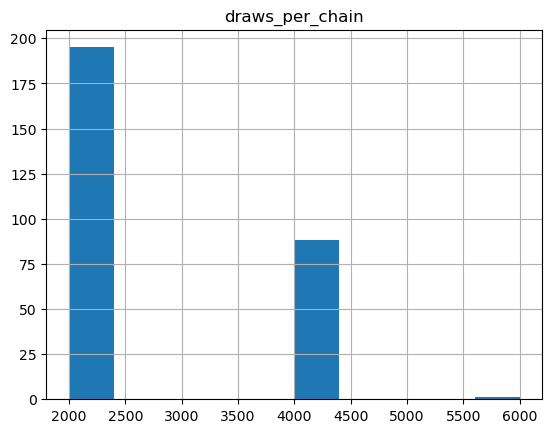

In [ ]:
real_val_conv_test_singles.hist('draws_per_chain')

array([[<Axes: title={'center': 'tune_per_chain'}>]], dtype=object)

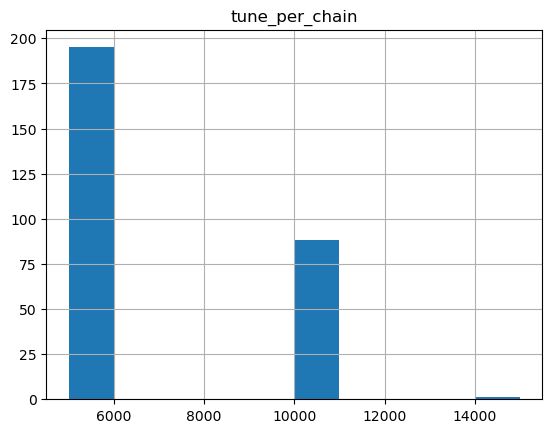

In [87]:
real_val_conv_test_singles.hist('tune_per_chain')

array([[<Axes: title={'center': 'draws_per_chain'}>]], dtype=object)

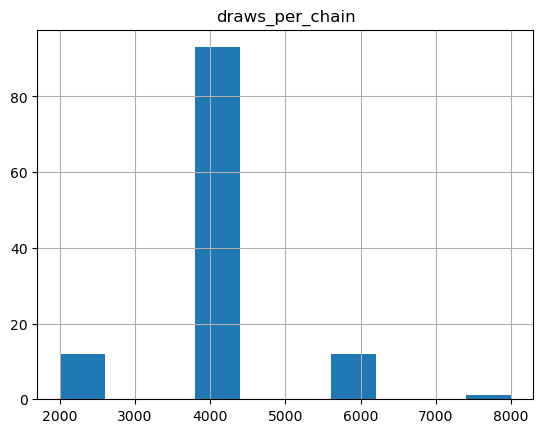

In [ ]:
real_val_conv_test_periodic.hist('draws_per_chain')

array([[<Axes: title={'center': 'tune_per_chain'}>]], dtype=object)

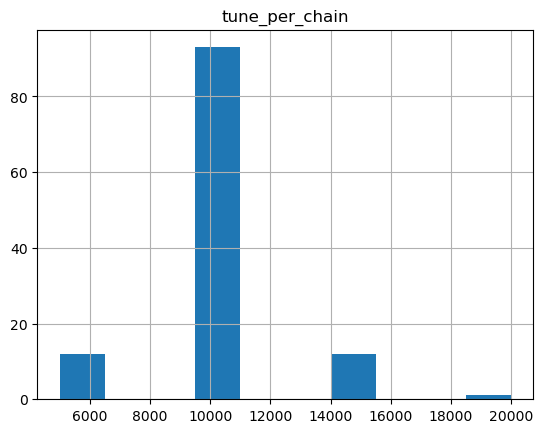

In [88]:
real_val_conv_test_periodic.hist('tune_per_chain')

In [ ]:
real_val_conv_test_periodic = converg_tests_periodic.copy()

real_val_conv_test_periodic['int_multi'] = np.nan
real_val_conv_test_periodic['correct'] = False
real_val_conv_test_periodic['alias'] = False
real_val_conv_test_periodic['true_per'] = np.nan

for indx, row in real_val_conv_test_periodic.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.periodiod
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_periodic.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)
        print(check_per)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = True
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = 1
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = False
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = round(per_int)
            
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known

        

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [96]:

7.727000/2.582000

2.992641363284276

In [97]:
# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['multiple'] == True) & (real_val_conv_test_singles['correct'] == False)].true_per, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['multiple'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
#          marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1.5, zorder = -1,  alpha = 0.8)


In [ ]:
real_val_conv_test_singles

In [ ]:
# a = (real_val_conv_test_singles['correct'] == True)
# b = ((real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False))
# c = (real_val_conv_test_singles['correct'] == True)


# real_val_conv_test_singles[a | b  | c]

# ok_ticids_singles = list(set(real_val_conv_test_singles[a | b  | c].TICID))


# multi_tic_singles = list(set(real_val_conv_test_singles[b].TICID))\


# correct_tic_singles = list(set(real_val_conv_test_singles[a].TICID))



KeyError: 'correct'

In [91]:
d = (real_val_conv_test_periodic['correct'] == True)
e =  (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)
f = (real_val_conv_test_periodic['correct'] == True)

ok_ticids_periodic = list(set(real_val_conv_test_periodic[d | e  | f].TICID))


multi_tic_periodic = list(set(real_val_conv_test_periodic[e].TICID))

correct_tic_periodic = list(set(real_val_conv_test_periodic[d ].TICID))





In [92]:
correct_ticids = list(set(correct_tic_periodic+correct_tic_singles
                         ))

NameError: name 'correct_tic_singles' is not defined

In [93]:
multi_ticids = set(multi_tic_periodic+multi_tic_singles)

NameError: name 'multi_tic_singles' is not defined

In [94]:
len(set(searched_tois.tic_id))

161

In [95]:
searched_tois = searched_tois.sort_values('pl_rade', ascending=False)

In [96]:
(0.102763)**2**2

0.00011151854570411509

In [97]:
big = list(searched_tois[searched_tois['transit_depth']>0.005].tic_id)

In [98]:
# searched_tois = searched_tois[searched_tois['tic_id'].isin(big)]

In [99]:
print(list(set(searched_tois.sort_values('sy_pnum', ascending=False).tic_id)))

['TIC 70899085', 'TIC 368287008', 'TIC 298074836', 'TIC 259168516', 'TIC 413248763', 'TIC 417931300', 'TIC 155867025', 'TIC 193336820', 'TIC 67512645', 'TIC 305048087', 'TIC 26054627', 'TIC 212957629', 'TIC 103633434', 'TIC 380887434', 'TIC 219860288', 'TIC 116483514', 'TIC 35009898', 'TIC 20182780', 'TIC 77156829', 'TIC 348755728', 'TIC 54962195', 'TIC 262530407', 'TIC 384888319', 'TIC 4070275', 'TIC 288144647', 'TIC 178709444', 'TIC 166184428', 'TIC 357501308', 'TIC 193634953', 'TIC 112115898', 'TIC 218795833', 'TIC 369327947', 'TIC 126606859', 'TIC 235678745', 'TIC 243641947', 'TIC 271971130', 'TIC 234994474', 'TIC 439867639', 'TIC 95057860', 'TIC 429358906', 'TIC 467179528', 'TIC 50618703', 'TIC 289164482', 'TIC 394357918', 'TIC 299798795', 'TIC 360156606', 'TIC 259233660', 'TIC 310380289', 'TIC 36724087', 'TIC 186810676', 'TIC 420112589', 'TIC 452866790', 'TIC 18318288', 'TIC 200322593', 'TIC 44898913', 'TIC 388076422', 'TIC 233602827', 'TIC 261135533', 'TIC 343628284', 'TIC 86263

In [100]:
len(glob.glob('../new_toi_data/t*'))#-len(failed_2)

247

In [101]:
failed_2

['TIC 116483514',
 'TIC 119585136',
 'TIC 142937186',
 'TIC 230055368',
 'TIC 357501308',
 'TIC 382602147',
 'TIC 417931300',
 'TIC 439867639',
 'TIC 470381900',
 'TIC 50618703']

In [ ]:


a = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)
b = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)
c = periodic (real_val_conv_test_singles['correct'] == True)


real_val_conv_test_singles[a | b  | c]

ok_ticids_singles = list(set(real_val_conv_test_singles[a | b  | c].TICID))


multi_tic_singles = list(set(real_val_conv_test_singles[b].TICID))\


correct_tic_singles = list(set(real_val_conv_test_singles[a].TICID))




d = (real_val_conv_test_periodic['correct'] == True)
e = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)
f = (real_val_conv_test_periodic['correct'] == True)

ok_ticids_periodic = list(set(real_val_conv_test_periodic[d | e  | f].TICID))


multi_tic_periodic = list(set(real_val_conv_test_periodic[e].TICID))

correct_tic_periodic = list(set(real_val_conv_test_periodic[d ].TICID))





In [112]:
searched_tois = searched_tois.reset_index(drop=True)
searched_tois

,tic_id,pl_orbper,transit_depth,sy_pnum,pl_rade
0,TIC 95057860,3.581919,0.039602,1,13.674956
1,TIC 46432937,1.440445,0.053079,1,13.316269
2,TIC 459323923,2.652062,0.118871,1,13.200000
3,TIC 165202476,2.908917,0.037378,1,12.441969
4,TIC 163539739,14.475670,0.038214,1,12.217789
...,...,...,...,...,...
186,TIC 307210830,2.253114,0.000592,5,0.837000
187,TIC 34068865,0.321923,0.000196,3,0.699000
188,TIC 77156829,0.860232,0.000364,3,0.685000
189,TIC 260708537,1.744700,0.000145,1,0.566000


In [113]:
len(set(searched_tois['tic_id']))

161

In [106]:
ticids   = []
mx_radii = []
indxs_unsort = []
for indx, row in searched_tois.iterrows():
    tic   = row['tic_id']
    if tic in ticids:
        continue
    small = searched_tois[searched_tois['tic_id'] == tic]
#     print(small, np.nanmax(small['pl_rade']))
    mx_radii.append(np.nanmax(small['pl_rade']))
    ticids.append(tic)
    indxs_unsort.append(indx)

ticids_set = np.array(ticids)[np.argsort(mx_radii)]

# sort_indxs = np.array(indxs_unsort)[np.argsort(radii)]
# radii = np.array(radii)#.astype(str)
indxs_unsort

[170,
 153,
 53,
 161,
 142,
 187,
 131,
 144,
 189,
 75,
 188,
 48,
 184,
 77,
 138,
 111,
 183,
 140,
 174,
 149,
 166,
 171,
 177,
 12,
 7,
 139,
 51,
 105,
 181,
 124,
 39,
 185,
 125,
 141,
 96,
 137,
 162,
 190,
 163,
 21,
 147,
 157,
 120,
 43,
 76,
 40,
 169,
 29,
 80,
 6,
 126,
 107,
 128,
 73,
 65,
 78,
 41,
 5,
 88,
 98,
 160,
 63,
 115,
 108,
 173,
 2,
 14,
 150,
 129,
 179,
 68,
 93,
 135,
 71,
 132,
 154,
 46,
 50,
 136,
 59,
 15,
 47,
 165,
 83,
 148,
 146,
 143,
 182,
 121,
 11,
 95,
 92,
 122,
 23,
 130,
 156,
 49,
 152,
 186,
 91,
 167,
 106,
 32,
 109,
 118,
 45,
 176,
 180,
 26,
 13,
 175,
 38,
 155,
 18,
 19,
 102,
 97,
 9,
 113,
 8,
 112,
 74,
 123,
 84,
 16,
 86,
 104,
 0,
 62,
 3,
 57,
 172,
 61,
 27,
 24,
 81,
 52,
 168,
 66,
 28,
 34,
 30,
 117,
 42,
 69,
 127,
 60,
 33,
 20,
 31,
 35,
 17,
 56,
 10,
 25,
 64,
 119,
 4,
 116,
 110,
 94]

In [115]:
print(list(searched_tois[searched_tois.pl_rade>5].tic_id))

['TIC 95057860', 'TIC 46432937', 'TIC 459323923', 'TIC 165202476', 'TIC 163539739', 'TIC 445751830', 'TIC 388076422', 'TIC 250111245', 'TIC 201177276', 'TIC 419411415', 'TIC 186810676', 'TIC 218795833', 'TIC 382602147', 'TIC 243641947', 'TIC 155867025', 'TIC 328513434', 'TIC 172370679', 'TIC 308120029', 'TIC 16005254', 'TIC 119585136', 'TIC 193634953', 'TIC 26054627', 'TIC 459762279', 'TIC 67512645', 'TIC 360156606', 'TIC 387690507', 'TIC 335590096', 'TIC 178709444', 'TIC 455784423', 'TIC 20182780', 'TIC 86263325', 'TIC 144700903', 'TIC 348755728', 'TIC 151825527', 'TIC 158588995', 'TIC 458419328', 'TIC 288144647', 'TIC 285048486']


In [103]:
glob.glob('../toi_data/target*/f*')

final_found_planets= pd.concat((pd.read_csv(f) for f in glob.glob('../toi_data/target*/f*')), ignore_index=True)


In [104]:
# final_found_planets = pd.read_csv('../toi_data/toi_')
final_found_planets

,ticid,gaia_id,candidate_id,ptype,t0_days,period_days,duration_days,depth,rp_rs,cosi,a_smaj,n_transits_obs,fit_is_current,source,default,notes,pymc_summary_json
0,348755728,5735744144510573696,Periodic|P=6.418736|t0=1522.27158,Periodic,1522.271576,6.418736,0.292154,0.011750,0.108397,0.191185,4.832704,8.0,True,BLS,True,NaN,"{""norm"": {""mean"": 1.001, ""median"": 1.000807003..."
1,348755728,5735744144510573696,Periodic|P=2.660384|t0=2258.77094,Periodic,2258.770943,2.660384,0.003608,0.014886,0.122007,0.003059,233.700266,8.0,True,BLS,True,NaN,"{""norm"": {""mean"": 0.999, ""median"": 0.999234919..."
2,348755728,5735744144510573696,Single|t0=1526.8084,Single,1526.808400,NaN,0.127629,0.007018,0.083775,0.010197,62.025905,NaN,True,DT_pass2,True,NaN,"{""norm"": {""mean"": 1.0, ""median"": 0.99987029040..."
3,348755728,5735744144510573696,Single|t0=2256.84336,Single,2256.843357,NaN,0.115934,0.022168,0.148889,0.014383,61.416840,NaN,True,DT_pass2,True,NaN,"{""norm"": {""mean"": 0.999, ""median"": 0.999462777..."
4,220479565,4770828304936109056,Periodic|P=44.372813|t0=1411.42478,Periodic,1411.424782,44.372813,0.030000,0.005033,NaN,NaN,NaN,7.0,False,BLS,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,420112589,2264839957167921024,Periodic|P=11.061935|t0=1691.53781,Periodic,1691.537806,11.061935,0.060000,0.003101,NaN,NaN,NaN,26.0,False,BLS,True,NaN,NaN
244,420112589,2264839957167921024,Periodic|P=25.296229|t0=2390.73215,Periodic,2390.732146,25.296229,0.140000,0.004770,NaN,NaN,NaN,3.0,False,BLS,True,NaN,NaN
245,441738827,1652137995942479744,Periodic|P=8.146957|t0=1712.81303,Periodic,1712.813033,8.146957,0.100094,0.002836,0.053256,0.015459,24.967885,31.0,True,BLS,True,NaN,"{""norm"": {""mean"": 1.0, ""median"": 1.00016919483..."
246,441738827,1652137995942479744,Single|t0=1735.26243,Single,1735.262433,NaN,0.128086,0.029886,0.172877,0.016159,59.761460,NaN,True,DT_pass2,True,NaN,"{""norm"": {""mean"": 1.0, ""median"": 1.00004154580..."


In [110]:
final_found_planets

,ticid,gaia_id,candidate_id,ptype,t0_days,period_days,duration_days,depth,rp_rs,cosi,a_smaj,n_transits_obs,fit_is_current,source,default,notes,pymc_summary_json
0,348755728,5735744144510573696,Periodic|P=6.418736|t0=1522.27158,Periodic,1522.271576,6.418736,0.292154,0.011750,0.108397,0.191185,4.832704,8.0,True,BLS,True,NaN,"{""norm"": {""mean"": 1.001, ""median"": 1.000807003..."
1,348755728,5735744144510573696,Periodic|P=2.660384|t0=2258.77094,Periodic,2258.770943,2.660384,0.003608,0.014886,0.122007,0.003059,233.700266,8.0,True,BLS,True,NaN,"{""norm"": {""mean"": 0.999, ""median"": 0.999234919..."
2,348755728,5735744144510573696,Single|t0=1526.8084,Single,1526.808400,NaN,0.127629,0.007018,0.083775,0.010197,62.025905,NaN,True,DT_pass2,True,NaN,"{""norm"": {""mean"": 1.0, ""median"": 0.99987029040..."
3,348755728,5735744144510573696,Single|t0=2256.84336,Single,2256.843357,NaN,0.115934,0.022168,0.148889,0.014383,61.416840,NaN,True,DT_pass2,True,NaN,"{""norm"": {""mean"": 0.999, ""median"": 0.999462777..."
4,220479565,4770828304936109056,Periodic|P=44.372813|t0=1411.42478,Periodic,1411.424782,44.372813,0.030000,0.005033,NaN,NaN,NaN,7.0,False,BLS,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,420112589,2264839957167921024,Periodic|P=11.061935|t0=1691.53781,Periodic,1691.537806,11.061935,0.060000,0.003101,NaN,NaN,NaN,26.0,False,BLS,True,NaN,NaN
244,420112589,2264839957167921024,Periodic|P=25.296229|t0=2390.73215,Periodic,2390.732146,25.296229,0.140000,0.004770,NaN,NaN,NaN,3.0,False,BLS,True,NaN,NaN
245,441738827,1652137995942479744,Periodic|P=8.146957|t0=1712.81303,Periodic,1712.813033,8.146957,0.100094,0.002836,0.053256,0.015459,24.967885,31.0,True,BLS,True,NaN,"{""norm"": {""mean"": 1.0, ""median"": 1.00016919483..."
246,441738827,1652137995942479744,Single|t0=1735.26243,Single,1735.262433,NaN,0.128086,0.029886,0.172877,0.016159,59.761460,NaN,True,DT_pass2,True,NaN,"{""norm"": {""mean"": 1.0, ""median"": 1.00004154580..."


In [ ]:

%matplotlib 

fig, axs = plt.subplots(1, figsize=(15, 50))


yticks = np.arange(161)



axs.scatter(searched_tois['pl_orbper'][indxs_unsort[::-1]], searched_tois['tic_id'].astype(str)[indxs_unsort[::-1]], color = 'b', marker = 'X', s = 50, zorder = 1E3)

axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['correct'] == True)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['correct'] == True)].TICID.astype(str), 
         marker='X', markersize=10,  markerfacecolor='none', markeredgecolor='red', linestyle='None', markeredgewidth = 2, zorder = 2000, alpha = 1)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].TICID.astype(str), 
         marker='d', markersize=15,  markerfacecolor='none', markeredgecolor='pink', linestyle='None', markeredgewidth = 2.5, zorder = 0,  alpha = 0.8)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].period, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='pink', linestyle='None', markeredgewidth = 2, zorder = 200,  alpha = 0.8)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['alias'] == False)].period, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['alias'] == False)].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='orange', linestyle='None', markeredgewidth = 2, zorder = 75,  alpha = 0.5)

axs.plot(real_val_conv_test_periodic[real_val_conv_test_periodic['converged'] == False].period, 
         real_val_conv_test_periodic[real_val_conv_test_periodic['converged'] == False].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='black', linestyle='None', markeredgewidth = 1, zorder = 20,  alpha = 0.6)

axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['correct'] == True)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['correct'] == True)].TICID.astype(str), 
         marker='D', markersize=13,  markerfacecolor='none', markeredgecolor='black', linestyle='None', markeredgewidth = 1.5, zorder = -1,  alpha = 0.6)

# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)].true_per, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)].TICID.astype(str), 
#          marker='X', markersize=10,  markerfacecolor='none', markeredgecolor='magenta', linestyle='None', markeredgewidth = 2, zorder = 1000, alpha = 1)

# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].true_per, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
#          marker='d', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1.5, zorder = 0,  alpha = 0.8)


# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].per, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
#          marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 2, zorder = 100,  alpha = 0.8)


# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['alias'] == False)].period, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['alias'] == False)].TICID.astype(str), 
#          marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='navy', linestyle='None', markeredgewidth = 2, zorder = 50,  alpha = 0.5)

# axs.plot(real_val_conv_test_singles[ (real_val_conv_test_singles['correct'] == False)].per, real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False)& (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
#          marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 1, zorder = 10,  alpha = 0.6)

# axs.plot(real_val_conv_test_singles[ (real_val_conv_test_singles['correct'] == True)].true_per, 
#          real_val_conv_test_singles[ (real_val_conv_test_singles['correct'] == True)].TICID.astype(str), 
#          marker='D', markersize=10,  markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 1, zorder = -1,  alpha = 0.6)


axs.scatter(searched_tois['pl_orbper'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E4)

axs.scatter(final_found_planets['Period'], 'TIC '+final_found_planets['TICID'].astype(str), color = 'goldenrod', marker = '2', s = 75, zorder = 1E4+1)

ticid_set = list(set(searched_tois['tic_id'].astype(str)))
axs.set_yticks(np.arange(161))
# axs.set_yticklabels(ticid_set)


axs.hlines(failed_2, -10, 100, color = 'k',ls = '--', zorder = -1, lw = 2)

# axs.scatter(searched_tois['Orbital Epoch Value'], searched_tois['TIC'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 100)
# axs.scatter(searched_tois['transit_depth'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E3)

# axs.set_yticks([str(tic) for tic in tic_ids])

# y1, y2 = axs.get_ylim()
# axs.vlines(0.25, y1, y2)
tick_vals = axs.get_yticks()

axs.set_ylim(-1, 161)
ax2 = axs.twinx()  


ax2.set_yticks(tick_vals)


ax2.set_yticklabels(sorted(mx_radii))
ax2.set_ylim(-1, 161)
    
# axs.set_ylim(y1, y2)
axs.set_xlabel('period')
axs.set_ylabel('TICID')
axs.set_xlim(-10, 100)

Using matplotlib backend: module://matplotlib_inline.backend_inline


KeyError: 'converged'